# Fetching Data

First we fetch the housing data from the url

In [1]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [2]:
fetch_housing_data()

After we fetched the data from the url we will write a function to extract the csv and turn it into a df. After this we will begin to explore the DF

In [3]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [4]:
housing=load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing.ocean_proximity.value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


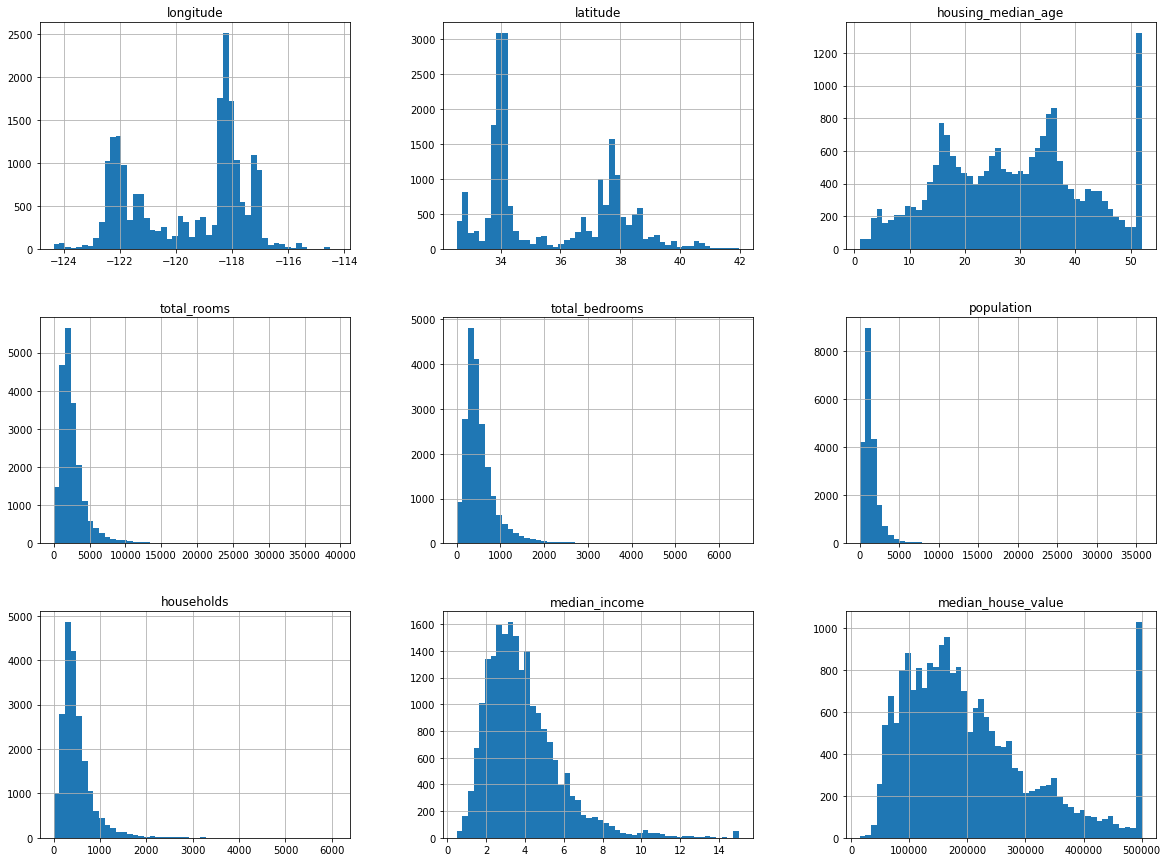

In [8]:
# only in a Jupyter notebook
%matplotlib inline   

import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

Notice values over 500,000 are caped in median_house_value (the target data). This means the model might not work properly with values over this range. Let's look at the data closer where values are over 500,000.

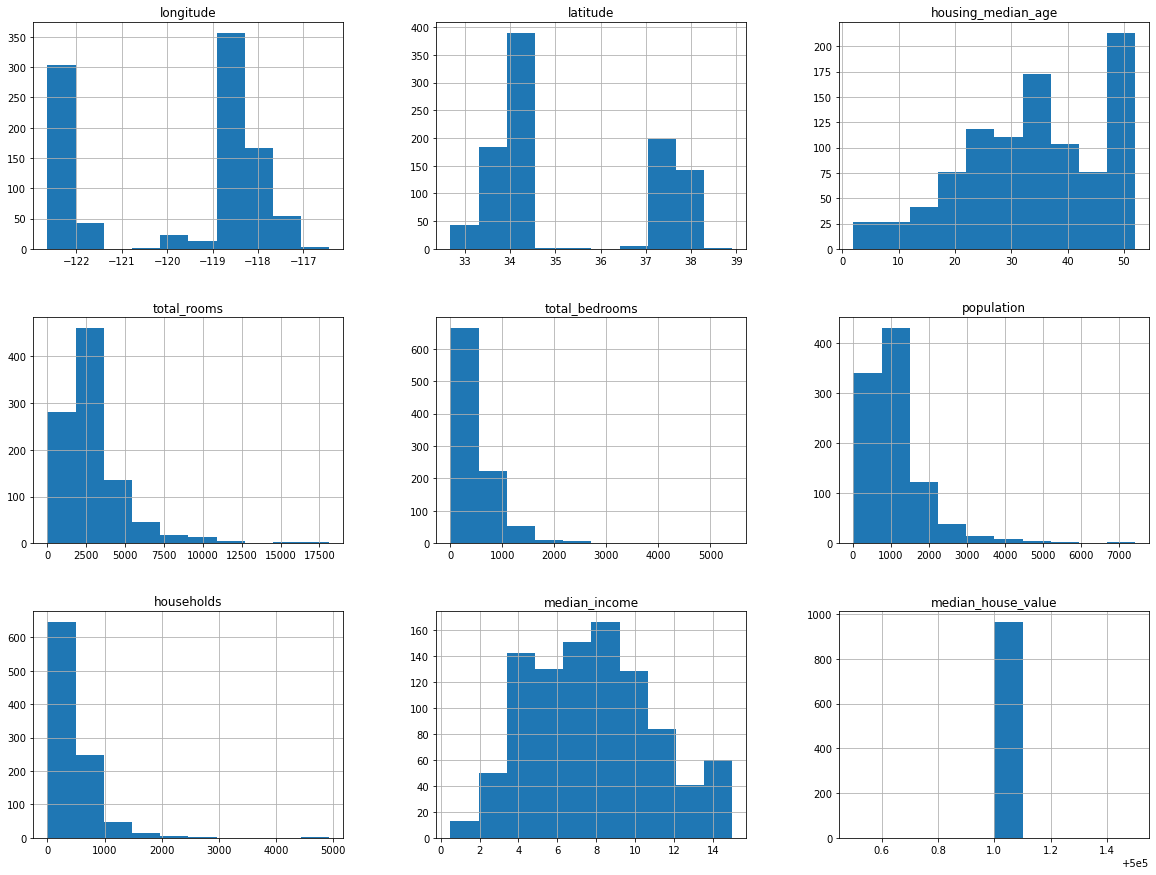

In [9]:
housing.loc[housing['median_house_value']>500000].hist(figsize=(20,15)) #(bins=50, figsize=(20,15))
plt.show()

In [10]:
housing['median_house_value'].loc[housing['median_house_value']>500000].value_counts()

500001.0    965
Name: median_house_value, dtype: int64

### Test set

Before doing any changes to our data we must set apart a testing set. Let's do this now before messing with the data and wrongly overfitting it.

In [11]:
#train test split function with numpy permutating indices from an np array
import numpy as np

def split_train_test(data, test_ratio):
    np.random.seed(42) #notice this is The Answer to the Ultimate Question of Life, the Universe, and Everything
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [12]:
train_set, test_set = split_train_test(housing, 0.2)
len(train_set)

16512

In [13]:
len(test_set)

4128

In [14]:
#lets see if the indexes are mismatched now
test_set.index

Int64Index([20046,  3024, 15663, 20484,  9814, 13311,  7113,  7668, 18246,
             5723,
            ...
             4653,  1783,  7608,     0, 10155, 15362, 16623, 18086,  2144,
             3665],
           dtype='int64', length=4128)

this can also be done with sklearn

In [15]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

Note: since we are taking our data from online source it would be a good idea toset an identifier to our current data. This will secure that our model doesnt change with a new data update. This could be done if the data has an identifier. If this is not possible we could set an index to current data and concatenate new data. Other possibility is ussing a mix of unchanging data variables such as longitude and latitude.

#### Categorical median income

The following classifies different income strata

In [16]:
housing["income_cat"] = pd.cut(housing["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5])

<AxesSubplot:>

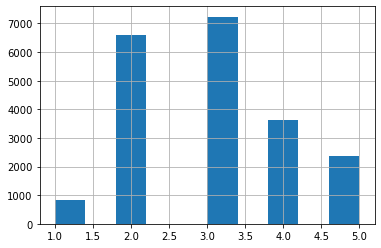

In [17]:
housing["income_cat"].hist()

with this we can run a stratified sampling

In [18]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [19]:
# lets check if it worked
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

3    0.350533
2    0.318798
4    0.176357
5    0.114583
1    0.039729
Name: income_cat, dtype: float64

Let's remove the income feature we came up with

In [20]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

Let's make a copy of the training set so we dont alter it while we play with it

In [21]:
housing = strat_train_set.copy()

### Visualize the Data

We will begin to plot the data in order to understand our data better 

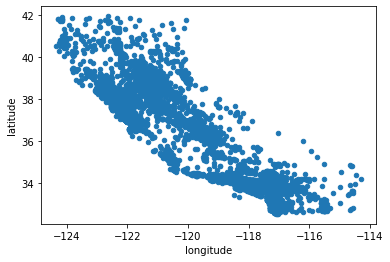

In [22]:
housing.plot(kind="scatter", x="longitude", y="latitude") #easy x, y axis assignation and scatterplot
plt.show() #remember this line is not always necessary

Yep, thats California all right. But now what? Lets set an alpha to visualize density

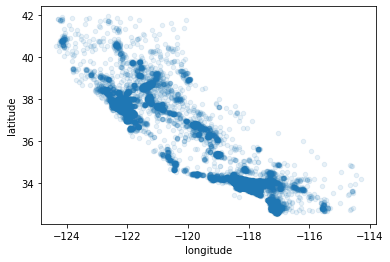

In [23]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
plt.show()

We can now dilusidate the bay area and LA and San diego. We can do better than that

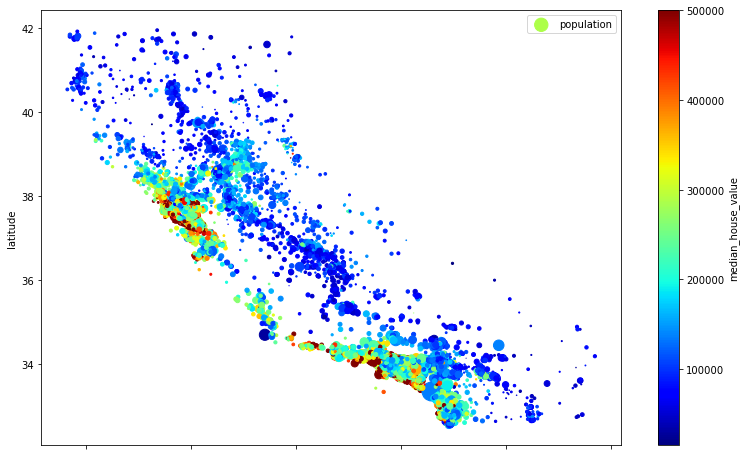

In [24]:
housing.plot(kind="scatter", x="longitude", y="latitude", #alpha=0.4,
             s=housing["population"]/100, #size given by population. Over 100 makes it 35 as max value
             label="population", #label on the right top
             figsize=(13,8),
             c="median_house_value", #color given by median h value
             cmap=plt.get_cmap("jet"), #this sets low values to blue and high values to red
             colorbar=True, #add a colorbar of what the color values represent
)
plt.legend()
plt.show()

### Correlations

Now let's look for correlations. We can start with the Pearson's r

In [25]:
corr_matrix = housing.corr()

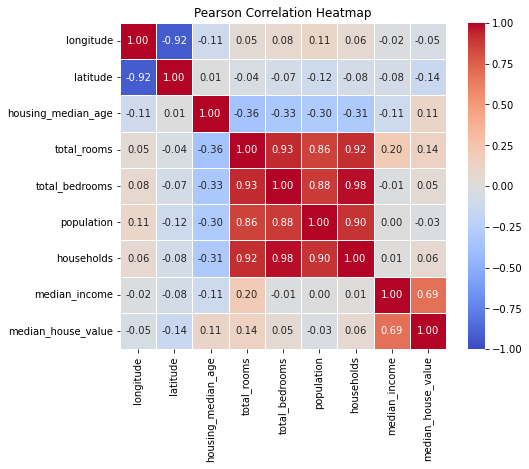

In [26]:
# Plot the heatmap
import seaborn as sns

plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(
    corr_matrix, 
    annot=True,          # Add the correlation values as text annotations
    cmap='coolwarm',     # Use a diverging color palette (e.g., blue for negative, red for positive)
    vmin=-1,             # Ensure the color scale spans from -1 to 1
    vmax=1,
    center=0,            # Center the color gradient at 0 (no correlation)
    fmt=".2f",           # Format the annotations to two decimal places
    linewidths=0.5,      # Add slight lines between cells for clarity
    square=True          # Ensure cells are square
)

plt.title('Pearson Correlation Heatmap')
plt.show()

Lets put special emphasis to our target feature so we understand our values better

In [27]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687160
total_rooms           0.135097
housing_median_age    0.114110
households            0.064506
total_bedrooms        0.047689
population           -0.026920
longitude            -0.047432
latitude             -0.142724
Name: median_house_value, dtype: float64

It is clear that the only significantly linearly correlated feature is the median income, which we kinda already knew. Other than that longitude and latittude are slightly correlated negatively which means that values tend to go lower as we go north or east.

Just in case, we will make a matrix scatter plotted just to spot if there is a polinomial or any other type of correlation

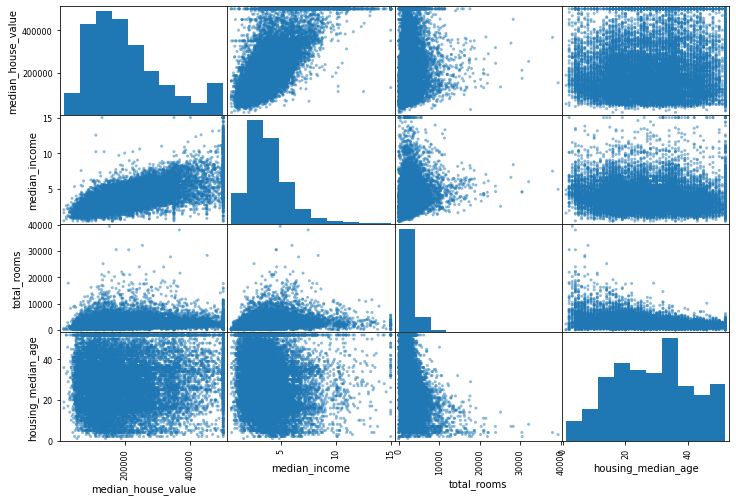

In [28]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

This confirms our previous suspicions. Lets see that median income up close

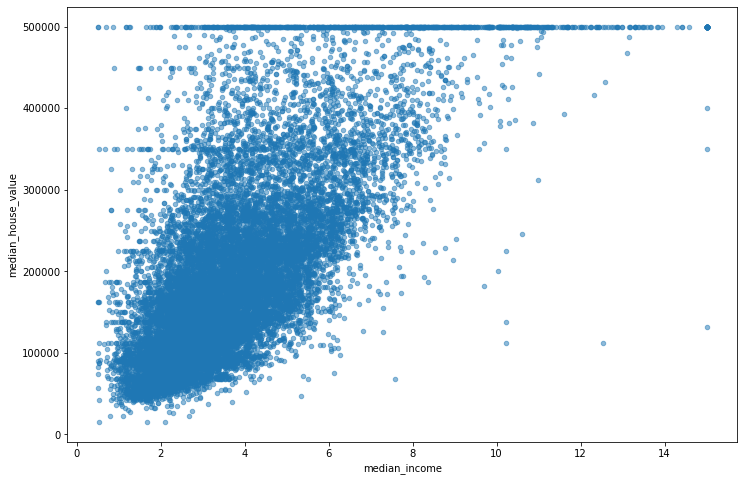

In [29]:
housing.plot(kind='scatter',y="median_house_value", x="median_income", alpha=0.5, figsize=(12, 8))
plt.show()

We can see a horizontal line at  $450,000$, another around $350,000$, perhaps one around $280,000$, and a few more below that. It's probably a good idea to get rid of them before the training. Also always remember to ask before removing things.

### Feature engineering

Notice the total number of rooms in a district is not very useful if you don’t know how many
households there are. What you really want is the **number_of_rooms_per_household**.
Similarly, the **total_number_of_bedrooms** by itself is not very useful: you probably
want to **compare** it to the **number_of_rooms**. And the **population_per_household** also
seems like an interesting attribute combination to look at. Let’s create these new
attributes.

In [30]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [31]:
housing.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,286600.0,<1H OCEAN,4.625369,0.223852,2.094395
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,340600.0,<1H OCEAN,6.008850,0.159057,2.707965
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,196900.0,NEAR OCEAN,4.225108,0.241291,2.025974


With these **new values** lets run a **correlation** again

In [32]:
corr_matrix = housing.corr()

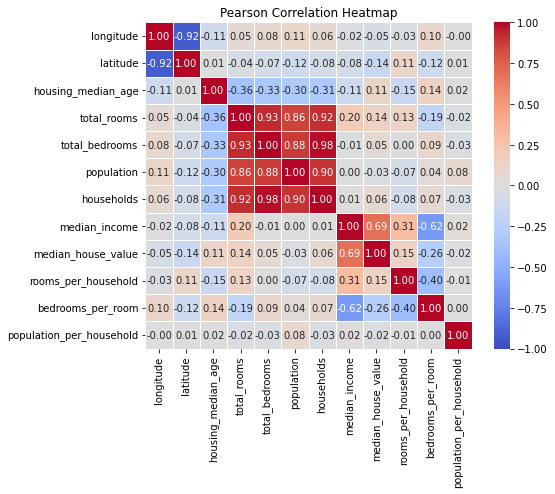

In [33]:
plt.figure(figsize=(8, 6)) # Set the figure size
sns.heatmap(
    corr_matrix, 
    annot=True,          # Add the correlation values as text annotations
    cmap='coolwarm',     # Use a diverging color palette (e.g., blue for negative, red for positive)
    vmin=-1,             # Ensure the color scale spans from -1 to 1
    vmax=1,
    center=0,            # Center the color gradient at 0 (no correlation)
    fmt=".2f",           # Format the annotations to two decimal places
    linewidths=0.5,      # Add slight lines between cells for clarity
    square=True          # Ensure cells are square
)

plt.title('Pearson Correlation Heatmap')
plt.show()

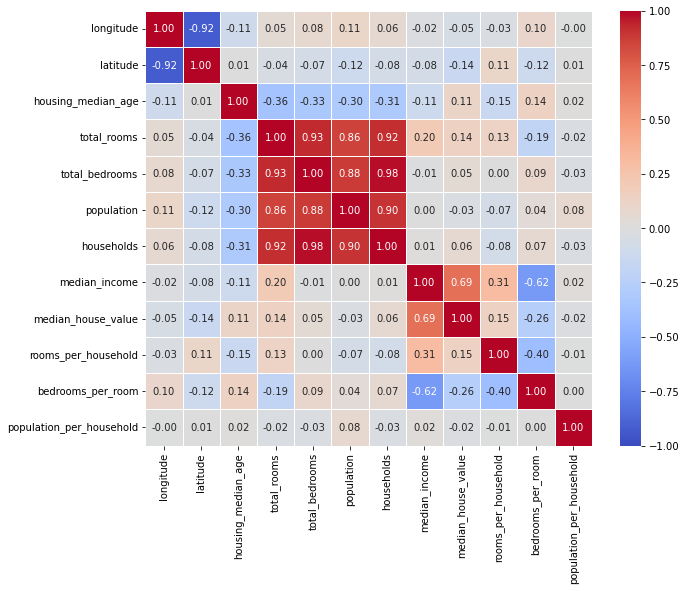

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            fmt="0.2f", linewidth=0.5)
plt.title=('Pearson Correlation Heatmap')
plt.show()

In [35]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687160
rooms_per_household         0.146285
total_rooms                 0.135097
housing_median_age          0.114110
households                  0.064506
total_bedrooms              0.047689
population_per_household   -0.021985
population                 -0.026920
longitude                  -0.047432
latitude                   -0.142724
bedrooms_per_room          -0.259984
Name: median_house_value, dtype: float64

Not bad! These featured engineering gave us a **better correlation** than the values all by **themselves**.

## Prepare data for ML

Time to prepare the data for a ML algorithm. Make sure you write functions since this will make the job easier to work on production. Let's start by reverting our changes.

In [36]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

#### Dealing with NAN data

Remember we have the feature **total_bedrooms** that has nan values we must deal with.

In [37]:
housing.isna().sum() #count nan values

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

Easier methods to deal with NAN values are: \
**Option 1:** Drop NAN values. \
**Option 2:** Drop the whole feature. \
**Option 3:** Replace NAN values with the median. 

In [38]:
#housing.dropna(subset=["total_bedrooms"])                                #option 1

#housing.drop("total_bedrooms", axis=1)                                   #option 2

median = housing["total_bedrooms"].median()                               #option 3
#housing["total_bedrooms"].fillna(median, inplace=True)

In [39]:
median

433.0

Option 3 can be done with an Scikit-Learn simple imputer function that makes the calculation of the median of all numerical features

In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [41]:
housing_num = housing.drop("ocean_proximity", axis=1) #df with only numerical values

In [42]:
imputer.fit(housing_num) #applying the method

SimpleImputer(strategy='median')

In [43]:
imputer.statistics_ #sklearn output

array([-118.51  ,   34.26  ,   29.    , 2119.5   ,  433.    , 1164.    ,
        408.    ,    3.5409])

In [44]:
housing_num.median().values #simple median function

array([-118.51  ,   34.26  ,   29.    , 2119.5   ,  433.    , 1164.    ,
        408.    ,    3.5409])

As you can see we get the **same median value** we would get with the traditional function. However it is **easier to input data** with sklearn like this:

In [45]:
X = imputer.transform(housing_num) #inputed median array

In [46]:
ousing_tr = pd.DataFrame(X, columns=housing_num.columns) #transformed inputed array to df 

#### Handling categorical values

Most ML algorithms rather work with numbers instead of categories so we'll use Scikit-Learn’s OrdinalEncoder class

In [47]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder() #ordinal encoder class

In [48]:
housing_cat = housing[["ocean_proximity"]] #ocean proximity column. only this categorical value

housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat) 
housing_cat_encoded[:10]

array([[0.],
       [0.],
       [4.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.]])

You can also see the original values of each category in an array like this

In [49]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

The integer values 0-4 might confuse the ML algoritm assigning some type of sense of sentiument analyisis to the problem. Because of this we might rather use one-hot-encoding

In [50]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder= OneHotEncoder()
housing_cat_1hot=cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

To save memory 1 hot encoding only saves the postions of the 1's. This is called a sparsed matrix. Howerver this can be tranformed to a regular array like this

In [51]:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

And again, you can also see the original values of each category in an array like this

In [52]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Note: With 1 hot encoding too many categories can slow down training and degrade performance. Be wary

### Custom transformers

Here is a small transformer class that adds
the combined attributes we discussed earlier:

In [53]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

In [54]:
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

It is a good practice to create a class of all the cleaning you would like to add using the scikit transform method. In this case it is a feature engineer method

#### Feature Scaling

To do feature scaling we could either normalize (values from 0 to 1) the data or standarize it (not recommended for neural networks). Must remember that standarization is not sensitive to outliers. For now we will use a StandardScaler for our data cleaning pipeline.  

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler())
])

In [56]:
housing_num_tr= num_pipeline.fit_transform(housing_num)

What about 1 hot encoding and categorical data? Not to worry we can use a full pipeline with the ColumnTransformer class and get all the data cleaned.

In [57]:
from sklearn.compose import ColumnTransformer

num_attribs=list(housing_num) #list of numerical features
cat_attribs=['ocean_proximity']

full_pipeline= ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

In [58]:
housing_prepared=full_pipeline.fit_transform(housing)

### ML Time!

Let's start with a simple linear regression model

In [59]:
from sklearn.linear_model import LinearRegression

lin_reg=LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [60]:
#lets look at the results in the model

some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [210644.60459286 317768.80697211 210956.43331178  59218.98886849
 189747.55849879]


In [61]:
print("Labels:", list(some_labels))

Labels: [286600.0, 340600.0, 196900.0, 46300.0, 254500.0]


We can see the predictions work but they're not accuarate. Let's meassure the error. In this case we'll use RMSE (root mean square error). Don't forget that the RMSE is given by the following formula: 

\begin{equation}
RMSE(\mathbf{X}, h)= \sqrt{\frac{1}{m}\sum_{i=1}^{m} (h(\mathbf{x}^{(i)})-y^{(i)})^2}
\end{equation}

Where $\mathbf{X}$ is a matrix, $m$ is the number of instances in the dataset, $\mathbf{x}^{(i)}$ is a vector of all the feature values excluding the label (a subset of $\mathbf{X}$), $h$ is the ML prediction also called hypothesis and $y^{(i)}$ is the label.

RMSE is generally the preferred performance measure for regression tasks.

Also remember that there are other ways to meassure error such as the Mean Absolute Error (MAE) given by the following formula:

\begin{equation}
MAE(\mathbf{X}, h)= \frac{1}{m}\sum_{i=1}^{m} |h(\mathbf{x}^{(i)})-y^{(i)}|
\end{equation}

Remember that the RMSE is more sensitive to outliers than the MAE. This is also why RMSE generally performs better in bell shaped curves since outliers are exponencially rare in this curves. For a better explanation of why this happens in a mathematical way focused in norms refer to page 44 of Hands on ML with Scikit-Learn, Keras and Tensorflow 2nd edition.

In [62]:
from sklearn.metrics import mean_squared_error

housing_predictions= lin_reg.predict(housing_prepared)
lin_mse=mean_squared_error(housing_labels, housing_predictions)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

68628.19819848922

Okay this model is underfitted. Our options are:
* Select a more powerful model
* Feed the algorithm with better features
* Reduce the constraints on the model (parameters or regularization)

So we'll use a more powerful model. we'll use a DecisionTreeRegressor which is capable of finding nonlinear relationships in the data.

In [63]:
from sklearn.tree import DecisionTreeRegressor

tree_reg= DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor()

In [64]:
#Lets evaluate the model

housing_predictions=tree_reg.predict(housing_prepared)
tree_mse=mean_squared_error(housing_labels, housing_predictions)
tree_rmse=np.sqrt(tree_mse)
tree_rmse

0.0

Well, we finally did it. We overfitted the data.

### Cross Validation

To evaluate our models we will use cross validation.

In [65]:
#10 fold cross validation for a regression tree
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [66]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [67]:
display_scores(tree_rmse_scores)

Scores: [69327.01708558 65486.39211857 71358.25563341 69091.37509104
 70570.20267046 75529.94622521 69895.20650652 70660.14247357
 75843.74719231 68905.17669382]
Mean: 70666.74616904806
Standard deviation: 2928.322738055112


The Decision Tree has a score of approximately 71,407, generally ±2,439. You would not have this information if you just used one validation set. But cross-validation comes at the cost of training the model several times, so it is not always possible. Now let's compute cross validation but for a regular Linear regression.

In [68]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [66782.73843989 66960.118071   70347.95244419 74739.57052552
 68031.13388938 71193.84183426 64969.63056405 68281.61137997
 71552.91566558 67665.10082067]
Mean: 69052.46136345083
Standard deviation: 2731.674001798347


That’s right: the Decision Tree model is overfitting so badly that it performs worse than the Linear Regression model. Let's now try a RandomForestRegressor

In [69]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor()

In [70]:
# RMSE of Random Forest
housing_predictions=forest_reg.predict(housing_prepared)
forest_mse=mean_squared_error(housing_labels, housing_predictions)
forest_rmse=np.sqrt(forest_mse)
forest_rmse

18680.294240259147

In [71]:
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [49557.6095063  47584.54435547 49605.349788   52325.13724488
 49586.9889247  53154.87424699 48800.48987508 47880.32844243
 52958.68645964 50046.17489414]
Mean: 50150.018373763225
Standard deviation: 1902.0697041387534


as you can see this is how you compare each model to see how well they perform. You can also save your finished models with pythons pickle module like this:

In [72]:
#from sklearn.externals import joblib
#joblib.dump(my_model, "my_model.pkl")
# and later...
#my_model_loaded = joblib.load("my_model.pkl")

#### Gridsearch

This lets you itterate all possible parameter combinations

In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

In [74]:
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [75]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

6 and 30 are the highest values so we should try with bigger values. We'll do it later...

In [76]:
grid_search.best_estimator_ #also it is possible to get the best estimator like this

RandomForestRegressor(max_features=6, n_estimators=30)

Also you can see the evaliuation scores like this...

In [77]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

63433.40391736115 {'max_features': 2, 'n_estimators': 3}
56049.06443637957 {'max_features': 2, 'n_estimators': 10}
52824.848527310685 {'max_features': 2, 'n_estimators': 30}
60924.41328448018 {'max_features': 4, 'n_estimators': 3}
52713.650694157855 {'max_features': 4, 'n_estimators': 10}
50660.92190603788 {'max_features': 4, 'n_estimators': 30}
59604.01184459288 {'max_features': 6, 'n_estimators': 3}
52347.604952708156 {'max_features': 6, 'n_estimators': 10}
49923.3473574243 {'max_features': 6, 'n_estimators': 30}
59308.345962472304 {'max_features': 8, 'n_estimators': 3}
52320.77872780119 {'max_features': 8, 'n_estimators': 10}
50080.73594153239 {'max_features': 8, 'n_estimators': 30}
62160.41351492645 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54391.4645181866 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60269.48857946438 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52791.4337224519 {'bootstrap': False, 'max_features': 3, 'n_estimators': 1

#### Feature importance

It is also possible to get the feature importance with gridsearch

In [78]:
feature_importances = grid_search.best_estimator_.feature_importances_

In [79]:
feature_importances

array([7.55720671e-02, 6.39878625e-02, 4.24072059e-02, 1.82928273e-02,
       1.68924417e-02, 1.75601900e-02, 1.66881781e-02, 3.03268232e-01,
       6.31565549e-02, 1.08958622e-01, 8.44196144e-02, 8.53515062e-03,
       1.73063945e-01, 8.08024120e-05, 2.96250425e-03, 4.15380176e-03])

In [80]:
#let's display them with their attributing names

extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(0.303268232301214, 'median_income'),
 (0.1730639450304893, 'INLAND'),
 (0.10895862174634885, 'pop_per_hhold'),
 (0.0844196144263057, 'bedrooms_per_room'),
 (0.07557206707255014, 'longitude'),
 (0.0639878625247799, 'latitude'),
 (0.06315655490931625, 'rooms_per_hhold'),
 (0.04240720593117473, 'housing_median_age'),
 (0.018292827323116517, 'total_rooms'),
 (0.017560189966804522, 'population'),
 (0.01689244166020893, 'total_bedrooms'),
 (0.01668817806453196, 'households'),
 (0.008535150622100876, '<1H OCEAN'),
 (0.0041538017589390725, 'NEAR OCEAN'),
 (0.0029625042500806965, 'NEAR BAY'),
 (8.080241203860085e-05, 'ISLAND')]

Here will resume what we promised we'll do later and also we'll do the exercises in chapter 2 of hands on ML